In [6]:
from PIL import Image
import numpy as np

#A2
img = Image.open('кот')
#A3+A4
img_gray = img.convert('L')
A = np.array(img_gray)
print(A)

[[173 173 174 ... 151 151 151]
 [173 173 173 ... 150 150 150]
 [172 172 173 ... 150 150 150]
 ...
 [ 13  20  17 ... 112 133 133]
 [ 22  14   2 ... 112 133 133]
 [  7  14  82 ... 132 139 139]]
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=610x385 at 0x7C2F01FBBED0>


#Часть А
##Загрузка файлов
В данном блоке мы открыли файл, а перед этим добавили фото в colab, чтобы можно было в дальнейшем производить с ней операции.
После открытия файла и обозначения за переменную е мы превратили её в ч/б формате. Затем получаем матрицу и выводим.

In [2]:
#РАЗЛОЖЕНИЕ Б1
U, s, Vt = np.linalg.svd(A, full_matrices=False)

#СЖАТИЕ Б2
rg = [1, 5, 10, 30, 100, min(A.shape)]
print(rg)

def f(U, s, Vt, r):
    rg_f = (U[:, :r] * s[:r]) @ Vt[:r, :]
    rg_f = np.clip(rg_f, 0, 255)
    return rg_f


res = []
for r in rg:
    A_r = f(U, s, Vt, r)
    res.append(A_r)
    print(r)


[1, 5, 10, 30, 100, 385]
1
5
10
30
100
385


#Часть Б
##Разложение
Обозначаем 3 переменные, 3 матрицы, которые нам в дальнейшем помогут (без нулевых элементов). Пусть U будет как информация о строках, Vt - информация о столбах, s - главные сингулярные значения.

##Сжатие
Вводим ранги по заданию и максимальный ранг матрицы. И затем создаем фнкцию, которая будет восстанавливать наше изображение. rg_f позволяет восстановить матрицу с заданным рангом, как раз таки это будет удобно для наших нескольких предлагаемых вариантов. Далее выполняем клипирование для чисел, которые могут выйти за пределы. В res сохраняем проделанное, то есть там и будут будущие 6 фото. Прогоняем всё через функцию.


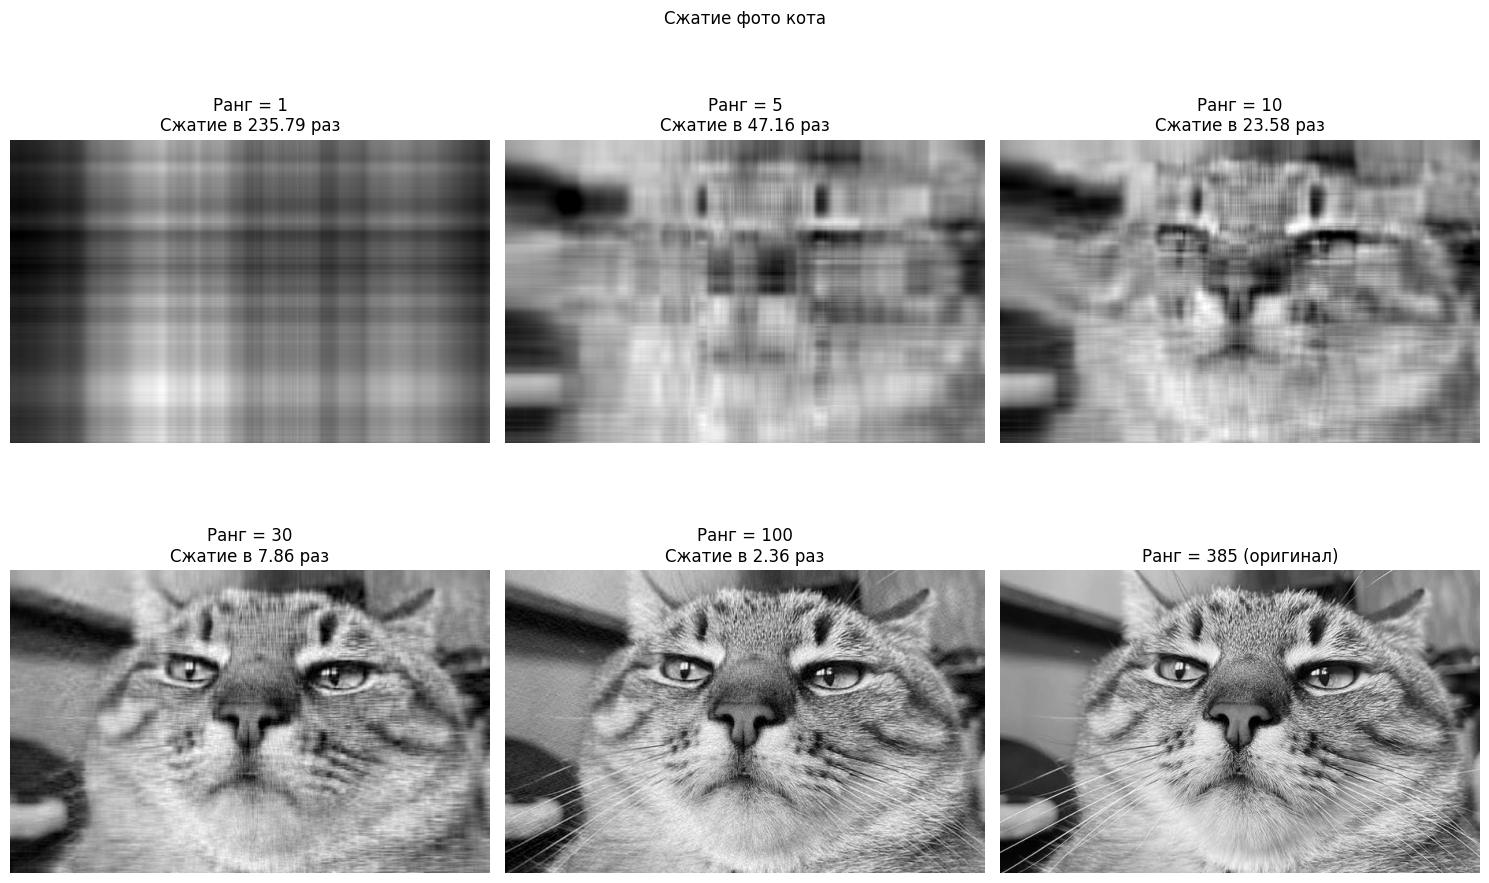

In [7]:
#В
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

h, w = A.shape
original = h * w

for i, (r, img_r) in enumerate(zip(rg, res)):
    new_size = r * (h + 1 + w)
    koef = original / new_size

    axes[i].imshow(img_r, cmap='gray')

    if r == min(A.shape):
        title = f'Ранг = {r} (оригинал)'
    else:
        title = f'Ранг = {r}\nСжатие в {koef:.2f} раз'

    axes[i].set_title(title)
    axes[i].axis('off')

plt.suptitle('Сжатие фото кота')
plt.tight_layout()
plt.show()

#Часть В
##Работа с фото
Для начала импорт библиотеки для работы. Для визуализации создаем сетку для 6 фото соответсвующих рангов. Сетка 2 строки и 3 столбца, каждое фото 15 на 10. Из матрицы делаем список для удобства работы, чтобы не вводить коэффициенты, будут просто индексы. Запускаем цикл.  Для каждого считаем сжатие, рисуем картинку и подписываем. Убираем оси координат. Добавляем ко всему общий заголовок и выводим получившиеся.   


In [ ]:
#Г
for r in rg:
    new_size = r*(h+1+w)
    koef = original/new_size
    print("Ранг", r, "Размер:", new_size, "Сжатие в", round(koef, 2), "раз")

Ранг 1 Размер: 1253 Сжатие в 312.75 раз
Ранг 5 Размер: 6265 Сжатие в 62.55 раз
Ранг 10 Размер: 12530 Сжатие в 31.28 раз
Ранг 30 Размер: 37590 Сжатие в 10.43 раз
Ранг 100 Размер: 125300 Сжатие в 3.13 раз
Ранг 626 Размер: 784378 Сжатие в 0.5 раз


#Часть Г
##Оформление сжатия к соответствующему рангу.
Делаем цикл. Оформляем подсчет ранга. Вывод

In [ ]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


#Ура! Проверка пройдена